In [7]:
from langgraph.graph import StateGraph, START, END 
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
import operator
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from dotenv import load_dotenv
from langchain.schema import SystemMessage, HumanMessage, BaseMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [6]:
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.2-1B-Instruct",
    task="text-generation",
    max_new_tokens=256,
    temperature=0.7
)
model = ChatHuggingFace(llm=llm)

print(model.invoke("Who are you?").content)

I'm an artificial intelligence model known as Llama. Llama stands for "Large Language Model Meta AI."


In [8]:
class JokeState(TypedDict):
    topic: str
    joke: str                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
    exp: str

In [11]:
def generate_joke(state: JokeState):
    prompt = f"Generate a funny joke on this topic. {state['topic']}"
    joke = model.invoke(prompt).content
    
    return {'joke': joke}

In [12]:
def explain_joke(state: JokeState):
    prompt = f"Explain this joke. {state['joke']}"
    explaination = model.invoke(prompt).content
    
    return {'exp': explaination}

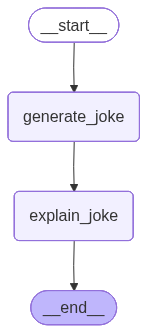

In [15]:
graph = StateGraph(JokeState)

graph.add_node("generate_joke", generate_joke)
graph.add_node("explain_joke",explain_joke)

graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke","explain_joke")
graph.add_edge("explain_joke",END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [16]:
config1 = {'configurable':{"thread_id":"1"}}
workflow.invoke({'topic':"pizza"}, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza go to therapy?\n\nBecause it was feeling crusty under the pressure!',
 'exp': 'This joke is a play on words, using the multiple meanings of "crusty" (both literally, as a type of baked crust, and figuratively, as feeling bitter or resentful).\n\nThe punchline "Because it was feeling crusty under the pressure" is a clever pun, as "pressure" can refer to both the external stress of the situation and the baked condition of the crust. The joke sets up the expectation that the pizza is just feeling stressed or overwhelmed, but then subverts it by revealing a literal, crusty origin for the feeling. It\'s a lighthearted, relatable joke that pokes fun at our everyday struggles and frustrations.'}

In [19]:
config2 = {'configurable':{"thread_id":"2"}}
workflow.invoke({'topic':"pasta"}, config=config2)

{'topic': 'pasta',
 'joke': 'Why was the pasta in therapy?\n\nBecause it was feeling a little "drained" and had a lot of "twists" and "turns" on its relationship with the sauce.',
 'exp': 'This joke is a play on words. The phrase "drained" has a double meaning here:\n\n* In cooking, pasta can be "drained" of its excess water, which is a common step in cooking pasta.\n* In psychology, "drained" can also be a euphemism for feeling emotionally exhausted or drained, as in having a lot of "twists" and "turns" in a difficult relationship.\n\nThe joke sets up a situation where a pasta (a type of food) is going to therapy, and the punchline "due to a lot of twists and turns on its relationship with the sauce" is a clever wordplay on the phrase "drained" having a double meaning. It\'s a lighthearted and humorous way to poke fun at the quirks of human relationships.'}

In [24]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why was the pasta in therapy?\n\nBecause it was feeling a little "drained" and had a lot of "twists" and "turns" on its relationship with the sauce.', 'exp': 'This joke is a play on words. The phrase "drained" has a double meaning here:\n\n* In cooking, pasta can be "drained" of its excess water, which is a common step in cooking pasta.\n* In psychology, "drained" can also be a euphemism for feeling emotionally exhausted or drained, as in having a lot of "twists" and "turns" in a difficult relationship.\n\nThe joke sets up a situation where a pasta (a type of food) is going to therapy, and the punchline "due to a lot of twists and turns on its relationship with the sauce" is a clever wordplay on the phrase "drained" having a double meaning. It\'s a lighthearted and humorous way to poke fun at the quirks of human relationships.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f105e9c-c6ad-6a0c

In [30]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why was the pasta in therapy?\n\nBecause it was feeling a little "drained" and had a lot of "twists" and "turns" on its relationship with the sauce.', 'exp': 'This joke is a play on words. The phrase "drained" has a double meaning here:\n\n* In cooking, pasta can be "drained" of its excess water, which is a common step in cooking pasta.\n* In psychology, "drained" can also be a euphemism for feeling emotionally exhausted or drained, as in having a lot of "twists" and "turns" in a difficult relationship.\n\nThe joke sets up a situation where a pasta (a type of food) is going to therapy, and the punchline "due to a lot of twists and turns on its relationship with the sauce" is a clever wordplay on the phrase "drained" having a double meaning. It\'s a lighthearted and humorous way to poke fun at the quirks of human relationships.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f105e9c-c6ad-6a0

In [31]:
workflow.get_state({"configurable": {"thread_id": "2", "checkpoint_id": "1f105e9c-ab31-67c4-8000-31b579967626"}})

StateSnapshot(values={'topic': 'pasta'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f105e9c-ab31-67c4-8000-31b579967626'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-02-09T19:01:51.144937+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f105e9c-ab2a-6582-bfff-78518c3de10e'}}, tasks=(PregelTask(id='a69b6951-556d-8019-8c3b-6e6fd17a14ef', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why was the pasta in therapy?\n\nBecause it was feeling a little "drained" and had a lot of "twists" and "turns" on its relationship with the sauce.'}),), interrupts=())

In [33]:
workflow.invoke(None, {"configurable": {"thread_id": "2", "checkpoint_id": "1f105e9c-ab31-67c4-8000-31b579967626"}})

{'topic': 'pasta',
 'joke': 'Here\'s one:\n\nWhy did the spaghetti go to therapy?\n\nBecause it was feeling tangled up in its emotions and was thinking it was the "dragging" point of the relationship.',
 'exp': 'This joke is a play on words. \n\nThe joke sets up the expectation that the question will ask why the spaghetti went to therapy, and how it relates to its emotions. However, the punchline is unexpected, as "tangled up" has a double meaning here.\n\nIn this case, "tangled up" refers to the spaghetti\'s physical shape, which is indeed twisted and knotted. \n\nOn the other hand, "tangled up" also means emotionally entangled or confused, as in being deeply involved in someone\'s emotions.\n\nSo, the joke is funny because the wordplay on "tangled up" creates a unexpected connection between the physical and emotional meanings, leading to a clever and silly punchline.'}

In [34]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Here\'s one:\n\nWhy did the spaghetti go to therapy?\n\nBecause it was feeling tangled up in its emotions and was thinking it was the "dragging" point of the relationship.', 'exp': 'This joke is a play on words. \n\nThe joke sets up the expectation that the question will ask why the spaghetti went to therapy, and how it relates to its emotions. However, the punchline is unexpected, as "tangled up" has a double meaning here.\n\nIn this case, "tangled up" refers to the spaghetti\'s physical shape, which is indeed twisted and knotted. \n\nOn the other hand, "tangled up" also means emotionally entangled or confused, as in being deeply involved in someone\'s emotions.\n\nSo, the joke is funny because the wordplay on "tangled up" creates a unexpected connection between the physical and emotional meanings, leading to a clever and silly punchline.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f10

In [37]:
workflow.update_state({"configurable": {"thread_id": "2", "checkpoint_id": "11f105e9c-ab31-67c4-8000-31b579967626"}}, {'topic':'samosa'})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f105ed7-fb55-6fb2-8000-2b0dfdffa68a'}}

In [38]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f105ed7-fb55-6fb2-8000-2b0dfdffa68a'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-02-09T19:28:23.317661+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '11f105e9c-ab31-67c4-8000-31b579967626'}}, tasks=(PregelTask(id='3e75f9f6-2d17-19ab-4c92-63d3cb4f8c2b', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pasta', 'joke': 'Here\'s one:\n\nWhy did the spaghetti go to therapy?\n\nBecause it was feeling tangled up in its emotions and was thinking it was the "dragging" point of the relationship.', 'exp': 'This joke is a play on words. \n\nThe joke sets up the expectation that the question will ask why the spaghetti went to therapy, and how it relates

In [40]:
workflow.invoke(None, {"configurable": {"thread_id": "2", "checkpoint_id": "1f105ed7-fb55-6fb2-8000-2b0dfdffa68a"}})

{'topic': 'samosa',
 'joke': 'Why did the samosa go to therapy?\n\nBecause it was feeling a little "folded" under the pressure.',
 'exp': 'This joke is a play on words. A samosa is a type of Indian pastry that is typically folded in half or in triangles to enclose its fillings. \n\nThe joke says that the samosa went to therapy because it was feeling "folded under the pressure." \n\nIn this case, "folded under the pressure" is a pun. The word "folded" has a double meaning here. In one sense, the samosa is folded in half or in triangles to make it more compact. But in another sense, "folded under the pressure" sounds like "folding under pressure," which means feeling overwhelmed or stressed.\n\nSo, the joke is saying that the samosa went to therapy because it was feeling stressed or overwhelmed by the demands of life, and the phrase "folded under the pressure" is a clever play on words to make a humorous connection between the samosa\'s physical shape and its emotional state.'}

In [41]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to therapy?\n\nBecause it was feeling a little "folded" under the pressure.', 'exp': 'This joke is a play on words. A samosa is a type of Indian pastry that is typically folded in half or in triangles to enclose its fillings. \n\nThe joke says that the samosa went to therapy because it was feeling "folded under the pressure." \n\nIn this case, "folded under the pressure" is a pun. The word "folded" has a double meaning here. In one sense, the samosa is folded in half or in triangles to make it more compact. But in another sense, "folded under the pressure" sounds like "folding under pressure," which means feeling overwhelmed or stressed.\n\nSo, the joke is saying that the samosa went to therapy because it was feeling stressed or overwhelmed by the demands of life, and the phrase "folded under the pressure" is a clever play on words to make a humorous connection between the samosa\'s physical shape and its emotiona